# Clusterização Binária com K-Means
## Segmentação de Clientes em Dois Grupos

Neste notebook, construiremos um modelo de **clusterização** com o algoritmo **K-Means** para separar clientes de um banco em **dois grupos** distintos com base em sua **renda mensal** e seu **gasto mensal no cartão de crédito**.

Ao contrário da regressão (que é um modelo **supervisionado**, onde temos uma variável alvo), a clusterização é uma técnica de **aprendizado não supervisionado**: os dados **não possuem rótulos**, e o algoritmo precisa descobrir sozinho quais amostras se parecem entre si.

### O Algoritmo K-Means (resumo)

O K-Means tenta dividir as amostras em **K grupos** seguindo este processo:

1. Escolhe **K centroides** iniciais (pontos de referência) de forma aleatória.
2. Atribui cada amostra ao centroide **mais próximo**.
3. Recalcula a posição de cada centroide como a **média** das amostras do seu grupo.
4. Repete os passos 2 e 3 até os centroides pararem de se mover (convergência).

O algoritmo busca minimizar a **inércia**: a soma das distâncias quadradas de cada ponto ao centroide do seu cluster.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset contém 160 clientes do banco, com duas características:
- **renda_mensal**: valor da renda mensal (R$)
- **gasto_cartao_mensal**: valor médio gasto no cartão de crédito por mês (R$)

In [2]:
df = pd.read_csv('dados_clientes_segmentacao.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 160 linhas × 2 colunas


,renda_mensal,gasto_cartao_mensal
0,3218.29,2054.66
1,3897.73,2923.22
2,9069.90,5787.57
3,3857.22,3165.97
4,2967.59,2206.75
5,12258.57,8794.42
6,4005.03,2597.01
7,3247.01,2759.49
8,13441.28,8747.56
9,13081.96,7176.67


In [3]:
df.describe().round(2)

,renda_mensal,gasto_cartao_mensal
count,160.00,160.00
mean,7779.07,5167.75
std,5134.00,3342.52
min,1939.17,1169.27
25%,3447.26,2320.87
50%,4191.76,3177.68
75%,12836.14,8415.51
max,18232.92,12912.99


## 3. Visualização dos Dados

Como temos apenas duas variáveis, podemos visualizar facilmente os dados em um gráfico de dispersão. Observe se já é possível enxergar **agrupamentos naturais**.

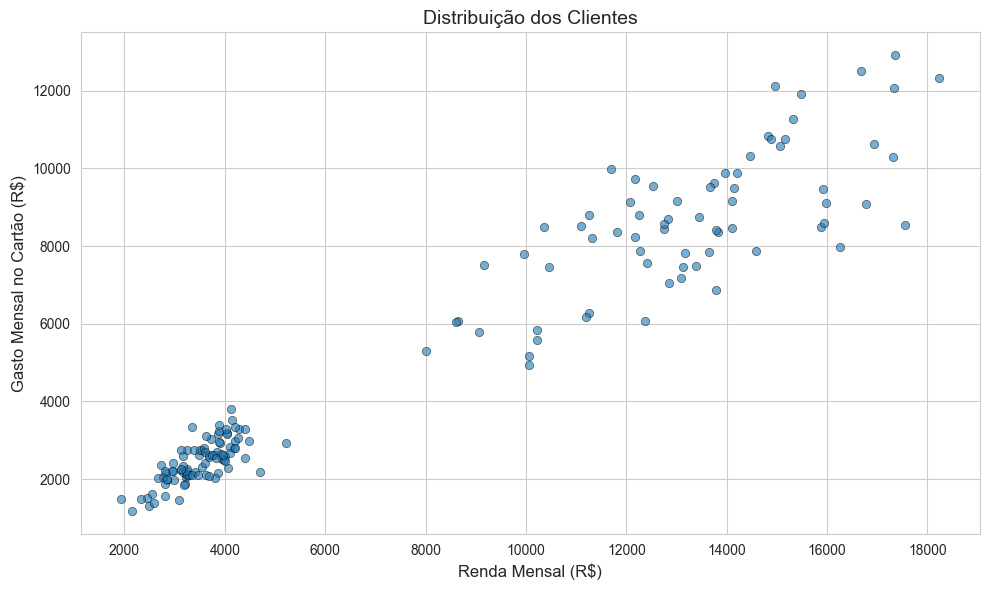

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['renda_mensal'], df['gasto_cartao_mensal'],
            alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Gasto Mensal no Cartão (R$)', fontsize=12)
plt.title('Distribuição dos Clientes', fontsize=14)
plt.tight_layout()
plt.show()

A olho nu já é possível identificar dois agrupamentos: um com clientes de renda mais baixa e gastos menores, e outro com renda alta e gastos maiores. Vamos deixar o K-Means descobrir essas divisões automaticamente.

## 4. Padronização dos Dados

O K-Means é baseado em **distância euclidiana**, o que significa que ele é **muito sensível à escala** das variáveis. Se uma variável estiver em uma escala muito maior que outra, ela dominará o cálculo das distâncias.

Por isso, é uma boa prática **padronizar** as variáveis (média = 0, desvio padrão = 1) antes de aplicar o K-Means.

In [5]:
scaler = StandardScaler()
X = df[['renda_mensal', 'gasto_cartao_mensal']].values
X_scaled = scaler.fit_transform(X)

print('Antes da padronização:')
print(f'  Renda     -> média: {X[:, 0].mean():.2f}, desvio: {X[:, 0].std():.2f}')
print(f'  Gasto     -> média: {X[:, 1].mean():.2f}, desvio: {X[:, 1].std():.2f}')
print('\nDepois da padronização:')
print(f'  Renda     -> média: {X_scaled[:, 0].mean():.2f}, desvio: {X_scaled[:, 0].std():.2f}')
print(f'  Gasto     -> média: {X_scaled[:, 1].mean():.2f}, desvio: {X_scaled[:, 1].std():.2f}')

Antes da padronização:
  Renda     -> média: 7779.07, desvio: 5117.93
  Gasto     -> média: 5167.75, desvio: 3332.06

Depois da padronização:
  Renda     -> média: 0.00, desvio: 1.00
  Gasto     -> média: 0.00, desvio: 1.00


## 5. Treinamento do K-Means com K=2

Vamos executar o K-Means pedindo **2 clusters**. Os principais parâmetros são:

- `n_clusters`: quantos grupos queremos formar.
- `n_init`: quantas inicializações aleatórias diferentes o algoritmo testa (ele escolhe a melhor). Como os centroides iniciais são aleatórios, rodar várias vezes ajuda a evitar mínimos locais ruins.
- `random_state`: garante reprodutibilidade dos resultados.

In [6]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X_scaled)

# Rótulos atribuídos a cada cliente (0 ou 1)
clusters = kmeans.labels_

print(f'Inércia (soma das distâncias quadradas aos centroides): {kmeans.inertia_:.2f}')
print(f'Iterações até convergência: {kmeans.n_iter_}')
print(f'\nQuantidade de clientes em cada cluster:')
print(pd.Series(clusters).value_counts().sort_index())

Inércia (soma das distâncias quadradas aos centroides): 40.01
Iterações até convergência: 4

Quantidade de clientes em cada cluster:
0    69
1    91
Name: count, dtype: int64


## 6. Centroides

Os **centroides** são os "pontos médios" de cada cluster. Como treinamos o modelo com dados padronizados, os centroides também estão na escala padronizada — vamos convertê-los de volta à escala original para interpretá-los.

In [7]:
# Centroides na escala padronizada
print('Centroides (escala padronizada):')
print(kmeans.cluster_centers_.round(3))

# Convertendo para a escala original
centroides_originais = scaler.inverse_transform(kmeans.cluster_centers_)
print('\nCentroides (escala original — R$):')
df_centroides = pd.DataFrame(
    centroides_originais.round(2),
    columns=['renda_mensal', 'gasto_cartao_mensal'],
    index=['Cluster 0', 'Cluster 1']
)
df_centroides

Centroides (escala padronizada):
[[ 1.088  1.06 ]
 [-0.825 -0.804]]

Centroides (escala original — R$):


,renda_mensal,gasto_cartao_mensal
Cluster 0,13347.19,8700.74
Cluster 1,3557.09,2488.89


## 7. Visualização dos Clusters

Vamos plotar os dados coloridos por cluster e marcar os centroides com um "X".

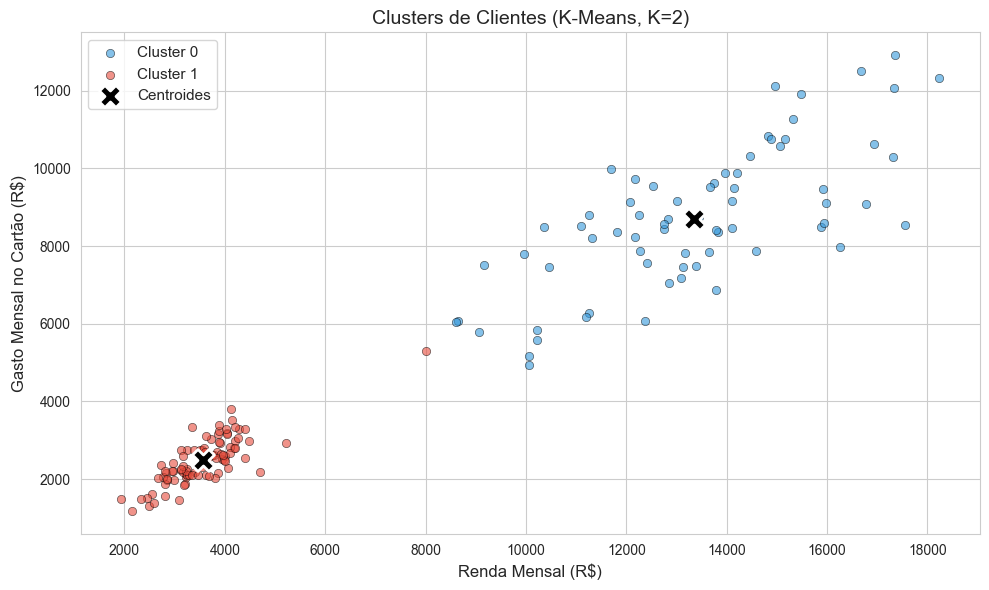

In [8]:
plt.figure(figsize=(10, 6))

cores = ['#3498db', '#e74c3c']
for cluster_id in range(2):
    pontos = df[clusters == cluster_id]
    plt.scatter(pontos['renda_mensal'], pontos['gasto_cartao_mensal'],
                c=cores[cluster_id], alpha=0.6,
                edgecolors='k', linewidths=0.5,
                label=f'Cluster {cluster_id}')

# Plotar centroides
plt.scatter(centroides_originais[:, 0], centroides_originais[:, 1],
            c='black', marker='X', s=250, edgecolors='white', linewidths=2,
            label='Centroides')

plt.xlabel('Renda Mensal (R$)', fontsize=12)
plt.ylabel('Gasto Mensal no Cartão (R$)', fontsize=12)
plt.title('Clusters de Clientes (K-Means, K=2)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Interpretação dos Clusters

Vamos adicionar a coluna de cluster ao DataFrame e analisar as características de cada grupo.

In [9]:
df['cluster'] = clusters

resumo = df.groupby('cluster').agg(
    n_clientes=('renda_mensal', 'count'),
    renda_media=('renda_mensal', 'mean'),
    renda_min=('renda_mensal', 'min'),
    renda_max=('renda_mensal', 'max'),
    gasto_medio=('gasto_cartao_mensal', 'mean'),
).round(2)
resumo

,n_clientes,renda_media,renda_min,renda_max,gasto_medio
cluster,,,,,
0,69,13347.19,8608.20,18232.92,8700.74
1,91,3557.09,1939.17,8000.00,2488.89


Com base no resumo acima, podemos dar **nomes interpretáveis** a cada cluster:

- **Cluster com renda média mais baixa** → "Clientes Padrão"
- **Cluster com renda média mais alta** → "Clientes Premium"

> **Observação**: o K-Means apenas separa os dados — quem dá o significado aos grupos é o analista, com base em conhecimento do negócio.

## 9. Avaliação: Coeficiente de Silhueta

Como na clusterização não temos uma "resposta certa" para comparar, usamos métricas que avaliam a **qualidade** dos clusters formados. A mais comum é o **coeficiente de silhueta**.

Para cada amostra, ele mede:
- **a**: distância média da amostra para os outros pontos do **mesmo** cluster (coesão).
- **b**: distância média da amostra para os pontos do **cluster vizinho mais próximo** (separação).

A silhueta de uma amostra é dada por:

$$s = \frac{b - a}{\max(a, b)}$$

Interpretação:
- **+1** → amostra está **bem dentro** do seu cluster e **longe** dos outros (ótimo).
- **0** → amostra está na **fronteira** entre dois clusters.
- **-1** → amostra provavelmente foi atribuída ao **cluster errado**.

In [10]:
score = silhouette_score(X_scaled, clusters)
print(f'Coeficiente de Silhueta: {score:.4f}')

if score > 0.7:
    print('-> Estrutura de clusters muito forte.')
elif score > 0.5:
    print('-> Estrutura de clusters razoável.')
elif score > 0.25:
    print('-> Estrutura de clusters fraca.')
else:
    print('-> Os clusters podem não ser confiáveis.')

Coeficiente de Silhueta: 0.7896
-> Estrutura de clusters muito forte.


## 10. Análise da Inércia

A **inércia** (soma das distâncias quadradas de cada ponto ao seu centroide) também ajuda a entender a qualidade do agrupamento. Quanto **menor** a inércia, **mais compactos** são os clusters.

Vamos comparar a inércia para K=1 (todos juntos) e K=2:

In [11]:
for k in [1, 2]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    print(f'K = {k}  ->  Inércia = {km.inertia_:.2f}')

K = 1  ->  Inércia = 320.00
K = 2  ->  Inércia = 40.01


A redução da inércia ao passar de K=1 para K=2 é grande, indicando que dividir em 2 grupos faz sentido para esses dados.

No próximo notebook, exploraremos como escolher o **melhor valor de K** quando não sabemos quantos clusters existem.

## 11. Classificando Novos Clientes

Com o modelo treinado, podemos atribuir novos clientes ao cluster mais próximo.

In [12]:
novos_clientes = pd.DataFrame({
    'renda_mensal':       [3000,  4500,  9000, 15000, 20000],
    'gasto_cartao_mensal':[2200,  3000,  6000,  9000, 12000]
})

# Importante: aplicar a MESMA padronização usada no treino
novos_scaled = scaler.transform(novos_clientes.values)
clusters_novos = kmeans.predict(novos_scaled)

novos_clientes['cluster'] = clusters_novos
novos_clientes

,renda_mensal,gasto_cartao_mensal,cluster
0,3000,2200,1
1,4500,3000,1
2,9000,6000,0
3,15000,9000,0
4,20000,12000,0


## Resumo

Neste notebook vimos:

1. **Clusterização** é uma técnica **não supervisionada**: descobrimos grupos sem rótulos pré-definidos.
2. O **K-Means** é simples e eficiente, mas é **sensível à escala** das variáveis — sempre padronize antes.
3. Os **centroides** representam o "perfil médio" de cada cluster e ajudam na interpretação.
4. O **coeficiente de silhueta** é a principal métrica para avaliar a qualidade dos clusters.
5. Cabe ao analista **dar significado** aos clusters encontrados, com base no contexto do problema.